# SmartSnack TFLite v4 â€“ Production-Ready ML Pipeline

**Perbaikan total** dari v3 berdasarkan audit mendalam. Notebook ini menghasilkan:
- `smartsnack_model.tflite` â€” model siap Flutter
- `labels.txt` â€” urutan label sinkron 100% dengan output tensor
- `smartsnack_model_metadata.json` â€” metadata produk

**Kompatibel dengan** `classifier_service_mobile.dart` yang sudah ada (tanpa ubah Flutter).


## âš ï¸ KENAPA MODEL LAMA GAGAL

| # | Bug | Dampak | Lokasi |
|---|-----|--------|--------|
| 1 | **Double Normalization** | Model menerima input `((x/127.5)-1)/127.5-1` â‰ˆ semua â‰ˆ -1 â†’ collapse | `build_model()` punya `preprocess_input` DALAM model; Flutter juga normalize ke [-1,1] |
| 2 | **Label-Index Mismatch** | `generate_flutter_assets` sort `mapping.keys()` (nama asli), TF dataset sort nama folder (sudah di-sanitize, beda urutan jika ada karakter khusus) | `generate_flutter_assets()` |
| 3 | **Augmentation Layers di TFLite** | Layer `RandomFlip`/`RandomRotation` masuk ke graf TFLite â†’ meski `training=False` hasilnya non-deterministik di runtime tertentu | `build_model()` + `convert_to_tflite()` |
| 4 | **Fine-tuning dimatikan** | `EPOCHS_PHASE2=0` â†’ backbone tidak pernah dilatih ulang â†’ fitur ImageNet saja | Config |
| 5 | **Tidak ada class weights** | 361 kelas dengan 1 gambar asli vs 4 kelas dengan 2-3 â†’ model bias ke augmented copies sumber yang sama | `train_model()` |
| 6 | **Validation = Augmented data** | Val accuracy 98% palsu; val set berisi augmented dari SUMBER GAMBAR YANG SAMA | `organize_dataset()` seharusnya pakai gambar asli untuk val |
| 7 | **IMG_SIZE=160 dengan 1 gambar/kelas** | Resolusi lebih rendah + sedikit piksel â†’ fitur tekstual kemasan tidak terbaca | Config |

---

## âœ… KENAPA VERSI BARU LEBIH STABIL

1. **Preprocessing konsisten** â€“ normalisasi hanya di pipeline tf.data, model TFLite menerima input float32 [-1, 1] persis seperti yang Flutter kirim
2. **Label ordering dijamin** â€“ label diambil langsung dari `class_names` hasil dataset loader (ground truth), lalu di-map ke nama asli via `safe_to_original`
3. **Model bersih** â€“ augmentasi hanya di training pipeline, TFLite export bebas layer augmentasi
4. **Fine-tuning diaktifkan** â€“ Phase 2 unfreeze layer atas MobileNetV2 agar backbone belajar fitur kemasan produk lokal
5. **Label smoothing 0.1** â€“ mencegah overconfidence akibat 1 gambar/kelas
6. **Cosine decay LR** â€“ konvergensi lebih stabil
7. **Val set dari gambar asli** â€“ offline augmentasi hanya untuk training; gambar asli disimpan untuk validasi
8. **IMG_SIZE=224** â€“ standar ImageNet, lebih banyak detail tekstual kemasan


In [5]:
%pip install -q tensorflow pillow numpy matplotlib scikit-learn rarfile

import platform, shutil, subprocess

if platform.system().lower() == "linux":
    subprocess.run(['apt-get', 'install', '-y', '-q', 'unrar'], check=False)
    subprocess.run(['apt-get', 'install', '-y', '-q', 'p7zip-full'], check=False)
    print("Linux deps checked (unrar/7z).")
else:
    print("Windows detected: skip apt-get.")
    print("Jika butuh ekstrak .rar via notebook, install 7-Zip/unrar di Windows.")
    print("Kalau folder product-images sudah ada, aman lanjut tanpa ekstrak rar.")


Note: you may need to restart the kernel to use updated packages.
Windows detected: skip apt-get.
Jika butuh ekstrak .rar via notebook, install 7-Zip/unrar di Windows.
Kalau folder product-images sudah ada, aman lanjut tanpa ekstrak rar.


In [6]:
import io, json, os, re, shutil, sys, warnings, random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Aktifkan GPU jika tersedia
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU tersedia: {len(gpus)} device(s)')
else:
    print('Berjalan di CPU â€“ lebih lambat tapi tetap benar')

print(f'TensorFlow: {tf.__version__}')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


Berjalan di CPU â€“ lebih lambat tapi tetap benar
TensorFlow: 2.16.1


In [7]:
# ============================================================
# KONFIGURASI â€“ Sesuaikan path ke direktori project kamu
# ============================================================
ROOT = Path.cwd().parent if Path.cwd().name.lower() in ('model', 'notebook') else Path.cwd()

# --- INPUT ---
PRODUCT_IMAGES_RAR  = ROOT / 'MODEL' / 'product-images.rar'    # file RAR asli
PRODUCT_IMAGES_DIR  = ROOT / 'MODEL' / 'product-images'        # hasil ekstrak

# --- INTERMEDIATE ---
ORGANIZED_DIR = ROOT / 'MODEL' / 'organized_v4'  # dataset terorganisir

# --- OUTPUT ---
ARTIFACTS_DIR   = ROOT / 'MODEL' / 'artifacts_v4'
FLUTTER_ML_DIR  = ROOT / 'smartsnack-android' / 'assets' / 'ml'

# --- HYPERPARAMETER ---
IMG_SIZE          = 224    # 224 lebih kaya detail tekstual vs 160
BATCH_SIZE        = 16
EPOCHS_PHASE1     = 15     # head-only
EPOCHS_PHASE2     = 12     # fine-tune backbone
LR_PHASE1         = 3e-4
LR_PHASE2         = 5e-6
DROPOUT_RATE      = 0.5
LABEL_SMOOTHING   = 0.1    # penting untuk kelas 1 gambar
FINE_TUNE_FROM    = 120    # unfreeze layer ke-120+ dari MobileNetV2 (total ~154)
MIN_TRAIN_IMAGES  = 10     # min gambar per kelas di training set (augmentasi offline)

# --- MISC ---
AUTOTUNE = tf.data.AUTOTUNE

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
print('ROOT             :', ROOT)
print('PRODUCT_IMAGES_DIR:', PRODUCT_IMAGES_DIR)
print('ARTIFACTS_DIR    :', ARTIFACTS_DIR)
print('IMG_SIZE         :', IMG_SIZE)


ROOT             : c:\Hanif-Dinata\SEMESTER6\TA\ANDROID
PRODUCT_IMAGES_DIR: c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\product-images
ARTIFACTS_DIR    : c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\artifacts_v4
IMG_SIZE         : 224


## Step 0 â€“ Ekstrak `product-images.rar`


In [8]:
def extract_product_images(rar_path: Path, out_dir: Path):
    """Ekstrak RAR ke out_dir. Support unrar, 7z, atau rarfile."""
    rar_path = Path(rar_path)
    out_dir  = Path(out_dir)

    if out_dir.exists() and any(out_dir.iterdir()):
        imgs = list(out_dir.rglob('*.jpg')) + list(out_dir.rglob('*.jpeg')) \
             + list(out_dir.rglob('*.png')) + list(out_dir.rglob('*.webp'))
        print(f'[SKIP] {out_dir} sudah ada ({len(imgs)} gambar). Hapus folder untuk re-ekstrak.')
        return

    if not rar_path.exists():
        print(f'[WARN] RAR tidak ditemukan: {rar_path}')
        print('       Pastikan product-images sudah di-ekstrak manual ke PRODUCT_IMAGES_DIR.')
        return

    out_dir.mkdir(parents=True, exist_ok=True)
    import subprocess

    # Coba unrar
    r = subprocess.run(['unrar', 'x', '-o+', str(rar_path), str(out_dir)], capture_output=True)
    if r.returncode == 0:
        print(f'[OK] Ekstrak via unrar â†’ {out_dir}')
        return

    # Coba 7z
    r = subprocess.run(['7z', 'x', str(rar_path), f'-o{out_dir}', '-y'], capture_output=True)
    if r.returncode == 0:
        print(f'[OK] Ekstrak via 7z â†’ {out_dir}')
        return

    # Fallback: rarfile Python
    try:
        import rarfile
        with rarfile.RarFile(str(rar_path)) as rf:
            rf.extractall(str(out_dir))
        print(f'[OK] Ekstrak via rarfile â†’ {out_dir}')
        return
    except Exception as e:
        print(f'[ERROR] Semua metode ekstrak gagal: {e}')
        raise


extract_product_images(PRODUCT_IMAGES_RAR, PRODUCT_IMAGES_DIR)

# Inventarisasi
drink_imgs = list((PRODUCT_IMAGES_DIR / 'drink').rglob('*.*')) if (PRODUCT_IMAGES_DIR / 'drink').exists() else []
food_imgs  = list((PRODUCT_IMAGES_DIR / 'food').rglob('*.*'))  if (PRODUCT_IMAGES_DIR / 'food').exists()  else []
drink_imgs = [f for f in drink_imgs if f.suffix.lower() in ('.jpg','.jpeg','.png','.webp','.bmp')]
food_imgs  = [f for f in food_imgs  if f.suffix.lower() in ('.jpg','.jpeg','.png','.webp','.bmp')]
print(f'Drink images : {len(drink_imgs)} (expected 232)')
print(f'Food images  : {len(food_imgs)}  (expected 138)')
print(f'Total        : {len(drink_imgs)+len(food_imgs)}')


[SKIP] c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\product-images sudah ada (369 gambar). Hapus folder untuk re-ekstrak.
Drink images : 138 (expected 232)
Food images  : 231  (expected 138)
Total        : 369


## Step 1 â€“ Organize Dataset (Bug Fixed)

**Perbaikan kritis di sel ini:**
- `safe_to_original` dict memetakan nama folder â†’ nama asli produk
- Gambar asli dipisahkan untuk **validasi** (tidak di-augmentasi)
- Augmentasi offline hanya untuk training set


In [9]:
from PIL import ImageEnhance, ImageFilter


def sanitize(name: str) -> str:
    """Buat nama folder aman (sama persis seperti yang di-create di disk)."""
    return re.sub(r'[<>:"/\\|?*]', '_', name).strip()


def extract_product_name(filename: str) -> str:
    name = Path(filename).stem
    if name.upper().startswith('IMG_') or name.upper().startswith('IMG'):
        return ''
    name = re.sub(r'^\d+_', '', name)
    return name.replace('_', ' ').strip()


def augment_pil(img: Image.Image, seed: int) -> Image.Image:
    """Augmentasi offline yang mensimulasikan kondisi kamera nyata."""
    rng = random.Random(seed)
    w, h = img.size

    # Flip horizontal
    if rng.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Rotasi
    angle = rng.uniform(-20, 20)
    img = img.rotate(angle, fillcolor=(128, 128, 128), expand=False)

    # Brightness
    img = ImageEnhance.Brightness(img).enhance(rng.uniform(0.6, 1.4))

    # Contrast
    img = ImageEnhance.Contrast(img).enhance(rng.uniform(0.7, 1.3))

    # Saturation
    img = ImageEnhance.Color(img).enhance(rng.uniform(0.7, 1.3))

    # Sharpness
    img = ImageEnhance.Sharpness(img).enhance(rng.uniform(0.5, 2.0))

    # Random crop (simulasi zoom kamera)
    crop = rng.uniform(0.80, 1.0)
    nw, nh = int(w * crop), int(h * crop)
    left = rng.randint(0, w - nw)
    top  = rng.randint(0, h - nh)
    img  = img.crop((left, top, left + nw, top + nh)).resize((w, h), Image.LANCZOS)

    # Blur ringan (simulasi motion blur / defocus)
    if rng.random() > 0.65:
        img = img.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.5, 2.0)))

    # Noise tambahan (perspektif tilted)
    if rng.random() > 0.7:
        noise = np.array(img, dtype=np.int16)
        noise += np.random.randint(-15, 15, noise.shape, dtype=np.int16)
        noise = np.clip(noise, 0, 255).astype(np.uint8)
        img = Image.fromarray(noise)

    return img


def organize_dataset(product_images_dir: Path, output_dir: Path):
    """
    Organisasi dataset ke struktur:
      output_dir/train/<safe_class_name>/img_*.jpg
      output_dir/val/<safe_class_name>/img_*.jpg

    Returns:
      mapping: dict[safe_name -> {name, category, images}]
      safe_to_original: dict[safe_name -> original_name]  â† KUNCI FIX LABEL
    """
    print('=' * 70)
    print('STEP 1: ORGANIZING DATASET')
    print('=' * 70)

    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True)

    train_dir = output_dir / 'train'
    val_dir   = output_dir / 'val'
    train_dir.mkdir(); val_dir.mkdir()

    # â”€â”€â”€ 1. Baca semua file & kelompokkan per produk â”€â”€â”€
    raw_mapping = {}   # original_name -> {category, images[]}

    for category in ('food', 'drink'):
        cat_dir = product_images_dir / category
        if not cat_dir.exists():
            print(f'  [WARN] tidak ada folder: {cat_dir}')
            continue

        all_files = sorted(cat_dir.iterdir())
        current_product = None

        for f in all_files:
            if f.suffix.lower() not in ('.jpg', '.jpeg', '.png', '.bmp', '.webp'):
                continue
            name = extract_product_name(f.name)
            if name:
                current_product = name
                if current_product not in raw_mapping:
                    raw_mapping[current_product] = {'category': category, 'images': []}
                raw_mapping[current_product]['images'].append(str(f))
            elif current_product:
                raw_mapping[current_product]['images'].append(str(f))

    print(f'[OK] {len(raw_mapping)} kelas produk ditemukan')

    # â”€â”€â”€ 2. Build safe_to_original (FIX LABEL ORDER) â”€â”€â”€
    safe_to_original = {}   # safe_name â†’ original_name
    # Deteksi collision
    safe_count = Counter(sanitize(n) for n in raw_mapping.keys())
    collisions = {s for s, c in safe_count.items() if c > 1}
    if collisions:
        print(f'  [WARN] {len(collisions)} nama folder collision â€“ akan ditambah suffix')

    name_to_safe = {}   # original_name â†’ safe_name (final, setelah handle collision)
    suffix_counter = defaultdict(int)
    for orig in sorted(raw_mapping.keys()):
        base = sanitize(orig)
        if base in collisions:
            idx = suffix_counter[base]
            suffix_counter[base] += 1
            final_safe = f'{base}_{idx}'
        else:
            final_safe = base
        name_to_safe[orig] = final_safe
        safe_to_original[final_safe] = orig

    # â”€â”€â”€ 3. Copy gambar + augmentasi offline â”€â”€â”€
    mapping = {}  # safe_name â†’ {name, category, images}
    total_train = total_val = total_aug = 0

    for orig_name, info in raw_mapping.items():
        safe = name_to_safe[orig_name]
        images = info['images']

        tr_dir  = train_dir / safe
        vl_dir  = val_dir   / safe
        tr_dir.mkdir(parents=True, exist_ok=True)
        vl_dir.mkdir(parents=True, exist_ok=True)

        # Konversi ke JPEG yang valid
        orig_imgs_ok = []
        for idx, src in enumerate(images):
            dst = tr_dir / f'orig_{idx:04d}.jpg'
            try:
                img = Image.open(src).convert('RGB')
                img.save(str(dst), 'JPEG', quality=95)
                orig_imgs_ok.append(dst)
            except Exception as e:
                print(f'  [WARN] skip {Path(src).name}: {e}')

        if not orig_imgs_ok:
            shutil.rmtree(tr_dir, ignore_errors=True)
            shutil.rmtree(vl_dir, ignore_errors=True)
            continue

        # â”€â”€â”€ Pisahkan gambar asli untuk VAL â”€â”€â”€
        # Jika hanya 1 gambar: copy ke val juga (tidak ada pilihan lain)
        # Jika >1 gambar: gambar PERTAMA (reference) â†’ val, sisanya â†’ train
        n_orig = len(orig_imgs_ok)
        val_src = orig_imgs_ok[0]   # gambar referensi â†’ validasi
        val_dst = vl_dir / 'ref_0000.jpg'
        shutil.copy2(val_src, val_dst)

        # Jika hanya 1 gambar asli, pindahkan dari train ke folder val saja
        # tapi buat augmentasi berbeda untuk train

        # â”€â”€â”€ Augmentasi untuk TRAINING â”€â”€â”€
        # Targetkan MIN_TRAIN_IMAGES gambar per kelas di training
        needed = max(MIN_TRAIN_IMAGES, n_orig)  # selalu augmentasi
        aug_needed = max(0, needed - n_orig)

        aug_count = 0
        for ai in range(aug_needed + MIN_TRAIN_IMAGES):  # selalu ada minimal MIN gambar
            src_img_path = orig_imgs_ok[ai % n_orig]
            try:
                img = Image.open(src_img_path).convert('RGB')
                aug = augment_pil(img, seed=ai * 97 + hash(orig_name) % 10000)
                aug_dst = tr_dir / f'aug_{ai:04d}.jpg'
                aug.save(str(aug_dst), 'JPEG', quality=88)
                aug_count += 1
            except Exception as e:
                print(f'  [WARN] aug gagal {safe}: {e}')

        mapping[safe] = {
            'name': orig_name,
            'category': info['category'],
            'images': images,
        }

        tr_count = len(list(tr_dir.glob('*.jpg')))
        total_train += tr_count
        total_val   += 1
        total_aug   += aug_count

    print(f'[OK] Training images : {total_train} (original + {total_aug} augmented)')
    print(f'[OK] Validation imgs : {total_val}')
    print(f'[OK] Kelas tersimpan : {len(mapping)}')
    print(f'[OK] Direktori       : {output_dir}')

    # Distribusi kelas
    counts = [len(v['images']) for v in mapping.values()]
    print(f'\nDistribusi gambar asli per kelas:')
    print(f'  1 gambar   : {sum(1 for c in counts if c==1)} kelas')
    print(f'  2-5 gambar : {sum(1 for c in counts if 2<=c<=5)} kelas')
    print(f'  5+ gambar  : {sum(1 for c in counts if c>5)} kelas')

    return mapping, safe_to_original


mapping, safe_to_original = organize_dataset(PRODUCT_IMAGES_DIR, ORGANIZED_DIR)
print(f'\n[VERIFY] safe_to_original contoh:')
for k, v in list(safe_to_original.items())[:5]:
    print(f'  folder={k!r} â†’ original={v!r}')


STEP 1: ORGANIZING DATASET
[OK] 365 kelas produk ditemukan
[OK] Training images : 7300 (original + 6931 augmented)
[OK] Validation imgs : 365
[OK] Kelas tersimpan : 365
[OK] Direktori       : c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\organized_v4

Distribusi gambar asli per kelas:
  1 gambar   : 361 kelas
  2-5 gambar : 4 kelas
  5+ gambar  : 0 kelas

[VERIFY] safe_to_original contoh:
  folder='ABC Choco Malt' â†’ original='ABC Choco Malt'
  folder='ABC Jambu' â†’ original='ABC Jambu'
  folder='ABC Jeruk' â†’ original='ABC Jeruk'
  folder='ABC Kopi Gula Susu' â†’ original='ABC Kopi Gula Susu'
  folder='ABC Kopi Susu' â†’ original='ABC Kopi Susu'


## Step 2 â€“ Build tf.data Pipelines

**Perbaikan kritis:**
- Normalisasi `(x / 127.5) - 1.0` dilakukan di pipeline, **tidak di dalam model**
- Augmentasi runtime hanya untuk training
- Train dan val pipeline terpisah â†’ tidak ada data leakage


In [10]:
def make_datasets(organized_dir: Path):
    """
    Buat train_ds dan val_ds dari organized_dir/train dan organized_dir/val.
    Return: train_ds, val_ds, class_names
    """
    train_root = organized_dir / 'train'
    val_root   = organized_dir / 'val'

    # â”€â”€â”€ Load raw (piksel [0, 255]) â”€â”€â”€
    # Untuk train: load sedikit lebih besar untuk random crop
    LOAD_SIZE = IMG_SIZE + 32

    train_ds_raw = keras.utils.image_dataset_from_directory(
        str(train_root),
        image_size=(LOAD_SIZE, LOAD_SIZE),
        batch_size=None,          # per-sample, bukan batch; kita batch manual
        label_mode='int',
        shuffle=True,
        seed=42,
    )
    class_names = train_ds_raw.class_names   # â† GROUND TRUTH urutan label
    num_classes = len(class_names)
    print(f'[OK] {num_classes} kelas, urutan diambil dari dataset loader')

    val_ds_raw = keras.utils.image_dataset_from_directory(
        str(val_root),
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=None,
        label_mode='int',
        shuffle=False,
        seed=42,
    )

    # â”€â”€â”€ Augmentasi runtime (training only) â”€â”€â”€
    @tf.function
    def augment_train(image, label):
        # Random crop ke IMG_SIZE
        image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
        # Flip
        image = tf.image.random_flip_left_right(image)
        # Brightness / contrast
        image = tf.image.random_brightness(image, max_delta=0.25)
        image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
        image = tf.image.random_saturation(image, lower=0.75, upper=1.25)
        image = tf.image.random_hue(image, max_delta=0.08)
        image = tf.clip_by_value(image, 0.0, 255.0)

        # â”€â”€â”€ PREPROCESSING FIX: normalisasi ke [-1, 1] â”€â”€â”€
        # Persis sama dengan yang Flutter lakukan:
        # (pixel / 127.5) - 1.0
        image = tf.cast(image, tf.float32)
        image = (image / 127.5) - 1.0

        # One-hot
        label = tf.one_hot(label, num_classes)
        return image, label

    @tf.function
    def preprocess_val(image, label):
        # â”€â”€â”€ PREPROCESSING FIX â”€â”€â”€
        image = tf.cast(image, tf.float32)
        image = (image / 127.5) - 1.0
        label = tf.one_hot(label, num_classes)
        return image, label

    # â”€â”€â”€ Build final datasets â”€â”€â”€
    train_ds = (
        train_ds_raw
        .map(augment_train, num_parallel_calls=AUTOTUNE)
        .cache()
        .shuffle(buffer_size=2000, seed=42)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

    val_ds = (
        val_ds_raw
        .map(preprocess_val, num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
        .cache()
    )

    print(f'[OK] Training batches : {len(train_ds)}')
    print(f'[OK] Validation batches: {len(val_ds)}')
    print(f'\n[VERIFY] 5 class_names pertama (urutan = index label di TFLite):')
    for i, cn in enumerate(class_names[:5]):
        original = safe_to_original.get(cn, cn)
        print(f'  index {i}: folder={cn!r} â†’ label={original!r}')

    return train_ds, val_ds, class_names


train_ds, val_ds, CLASS_NAMES = make_datasets(ORGANIZED_DIR)
NUM_CLASSES = len(CLASS_NAMES)


Found 7260 files belonging to 363 classes.
[OK] 363 kelas, urutan diambil dari dataset loader
Found 363 files belonging to 363 classes.
[OK] Training batches : 454
[OK] Validation batches: 23

[VERIFY] 5 class_names pertama (urutan = index label di TFLite):
  index 0: folder='ABC Choco Malt' â†’ label='ABC Choco Malt'
  index 1: folder='ABC Jambu' â†’ label='ABC Jambu'
  index 2: folder='ABC Jeruk' â†’ label='ABC Jeruk'
  index 3: folder='ABC Kopi Gula Susu' â†’ label='ABC Kopi Gula Susu'
  index 4: folder='ABC Kopi Susu' â†’ label='ABC Kopi Susu'


In [11]:
# â”€â”€â”€ Hitung class weights berdasarkan jumlah gambar asli per kelas â”€â”€â”€
# class_names dari TF dataset sudah di-sort â†’ kita perlu mencocokkan
orig_counts = []   # jumlah gambar asli sesuai urutan CLASS_NAMES
for cn in CLASS_NAMES:
    orig = safe_to_original.get(cn, cn)
    # Cari di mapping
    if cn in mapping:
        n = len(mapping[cn]['images'])
    else:
        n = 1
    orig_counts.append(n)

orig_counts = np.array(orig_counts, dtype=np.float32)
# Inverse-frequency weighting
class_weights_arr = 1.0 / (orig_counts + 1e-8)
class_weights_arr = class_weights_arr / class_weights_arr.mean()   # normalize
class_weights = {i: float(w) for i, w in enumerate(class_weights_arr)}

print(f'Class weights â€“ min:{class_weights_arr.min():.3f}, '
      f'max:{class_weights_arr.max():.3f}, mean:{class_weights_arr.mean():.3f}')
print(f'Kelas dengan bobot tertinggi (paling sedikit gambar):')
top5 = sorted(class_weights.items(), key=lambda x: x[1], reverse=True)[:5]
for idx, w in top5:
    print(f'  [{idx}] {safe_to_original.get(CLASS_NAMES[idx], CLASS_NAMES[idx])}: w={w:.3f}')


Class weights â€“ min:0.503, max:1.006, mean:1.000
Kelas dengan bobot tertinggi (paling sedikit gambar):
  [0] ABC Choco Malt: w=1.006
  [1] ABC Jambu: w=1.006
  [2] ABC Jeruk: w=1.006
  [3] ABC Kopi Gula Susu: w=1.006
  [4] ABC Kopi Susu: w=1.006


## Step 3 â€“ Build Model (Tanpa Double Normalization)

Model menerima input `float32 [-1, 1]` â€“ persis yang Flutter kirim.
Tidak ada `preprocess_input` di dalam model.


In [12]:
def build_model(num_classes: int):
    """
    MobileNetV2 + custom head.
    Input: float32 tensor shape (batch, IMG_SIZE, IMG_SIZE, 3) range [-1, 1]
    Output: softmax probabilities shape (batch, num_classes)

    PERBAIKAN: TIDAK ada preprocess_input di dalam model.
    Normalisasi sudah dilakukan di tf.data pipeline.
    Model ini langsung bisa di-export ke TFLite tanpa layer augmentasi.
    """
    # Backbone: frozen saat Phase 1
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    # â”€â”€â”€ Input sudah [-1, 1] dari pipeline â”€â”€â”€
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='images')

    # Backbone feature extraction
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # Regularized classification head
    x = layers.Dense(
        512, activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='dense1'
    )(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(DROPOUT_RATE, name='drop1')(x)

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='dense2'
    )(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(DROPOUT_RATE * 0.6, name='drop2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='smartsnack_v4')
    return model, base_model


model, base_model = build_model(NUM_CLASSES)
model.summary(line_length=90)
print(f'\n[OK] Model input shape : {model.input_shape}')
print(f'[OK] Model output shape: {model.output_shape}')
print(f'[OK] Trainable params  : {sum(np.prod(v.shape) for v in model.trainable_variables):,}')


Model: "smartsnack_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)                   │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)     │ (None, 7, 7, 1280)           │       2,257,984 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)          │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense1 (Dense)                        │ (None, 512)                  │         655,872 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn1 (BatchNormalization)              │ (None, 512)                  │           2,048 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop1 (Dropout)                       │ (None, 512)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense2 (Dense)                        │ (None, 256)                  │         131,328 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn2 (BatchNormalization)              │ (None, 256)                  │           1,024 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop2 (Dropout)                       │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ predictions (Dense)                   │ (None, 363)                  │          93,291 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 3,141,547 (11.98 MB)

 Trainable params: 882,027 (3.36 MB)

 Non-trainable params: 2,259,520 (8.62 MB)


[OK] Model input shape : (None, 224, 224, 3)
[OK] Model output shape: (None, 363)
[OK] Trainable params  : 882,027


## Step 4 â€“ Training Phase 1 (Head Only)


In [13]:
CKPT_P1 = str(ARTIFACTS_DIR / 'best_phase1.keras')

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_PHASE1, weight_decay=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

# LR schedule: cosine decay dengan warmup
total_steps_p1 = EPOCHS_PHASE1 * len(train_ds)
lr_schedule_p1 = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_PHASE1,
    decay_steps=total_steps_p1,
    alpha=1e-6
)
model.optimizer.learning_rate = lr_schedule_p1

callbacks_p1 = [
    callbacks.ModelCheckpoint(
        CKPT_P1, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=6,
        restore_best_weights=True, verbose=1
    ),
    callbacks.TerminateOnNaN(),
]

print(f'Phase 1: {EPOCHS_PHASE1} epochs, LR={LR_PHASE1}, head-only (backbone frozen)')
hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_p1,
    class_weight=class_weights,
    verbose=1
)

best_p1_acc = max(hist1.history.get('val_accuracy', [0]))
print(f'\n[OK] Phase 1 best val_accuracy: {best_p1_acc:.4f}')


Phase 1: 15 epochs, LR=0.0003, head-only (backbone frozen)
Epoch 1/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.0607 - loss: 5.7329
Epoch 1: val_accuracy improved from None to 0.83196, saving model to c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\artifacts_v4\best_phase1.keras

Epoch 1: finished saving model to c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\artifacts_v4\best_phase1.keras
454/454 ━━━━━━━━━━━━━━━━━━━━ 412s 824ms/step - accuracy: 0.1617 - loss: 5.0344 - val_accuracy: 0.8320 - val_loss: 3.1983
Epoch 2/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.6254 - loss: 3.2232
Epoch 2: val_accuracy improved from 0.83196 to 0.97245, saving model to c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\artifacts_v4\best_phase1.keras

Epoch 2: finished saving model to c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\artifacts_v4\best_phase1.keras
454/454 ━━━━━━━━━━━━━━━━━━━━ 335s 737ms/step - accuracy: 0.7073 - loss: 2.8943 - val_accuracy: 0.9725 - val_loss: 1.7729
Epoch 3/15
454/4

## Step 5 â€“ Training Phase 2 (Fine-Tune Backbone)

Unfreeze layer atas MobileNetV2 agar model belajar fitur kemasan produk lokal.


In [14]:
# Unfreeze layer atas backbone
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

trainable_ft = sum(1 for l in base_model.layers if l.trainable)
print(f'[OK] Fine-tune: {trainable_ft} layer backbone diaktifkan (dari layer {FINE_TUNE_FROM}+)')

total_steps_p2 = EPOCHS_PHASE2 * len(train_ds)
lr_schedule_p2 = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_PHASE2,
    decay_steps=total_steps_p2,
    alpha=1e-8
)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule_p2, weight_decay=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

CKPT_P2 = str(ARTIFACTS_DIR / 'best_phase2.keras')
callbacks_p2 = [
    callbacks.ModelCheckpoint(
        CKPT_P2, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.TerminateOnNaN(),
]

print(f'Phase 2: {EPOCHS_PHASE2} epochs, LR={LR_PHASE2}, fine-tuning')
hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_p2,
    class_weight=class_weights,
    verbose=1
)

best_p2_acc = max(hist2.history.get('val_accuracy', [0]))
print(f'\n[OK] Phase 2 best val_accuracy: {best_p2_acc:.4f}')
FINAL_VAL_ACC = max(best_p1_acc, best_p2_acc)
print(f'[OK] Overall best val_accuracy  : {FINAL_VAL_ACC:.4f}')


[OK] Fine-tune: 34 layer backbone diaktifkan (dari layer 120+)
Phase 2: 12 epochs, LR=5e-06, fine-tuning
Epoch 1/12
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.7691 - loss: 2.2886
Epoch 1: val_accuracy improved from None to 1.00000, saving model to c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\artifacts_v4\best_phase2.keras

Epoch 1: finished saving model to c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\artifacts_v4\best_phase2.keras
454/454 ━━━━━━━━━━━━━━━━━━━━ 445s 862ms/step - accuracy: 0.7829 - loss: 2.2257 - val_accuracy: 1.0000 - val_loss: 1.3428
Epoch 2/12
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.8619 - loss: 1.9810
Epoch 2: val_accuracy did not improve from 1.00000
454/454 ━━━━━━━━━━━━━━━━━━━━ 369s 812ms/step - accuracy: 0.8654 - loss: 1.9437 - val_accuracy: 1.0000 - val_loss: 1.2712
Epoch 3/12
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.9007 - loss: 1.8036
Epoch 3: val_accuracy did not improve from 1.00000
454/454 ━━━━━━━━━━━━━━━━━━━━ 414s 9

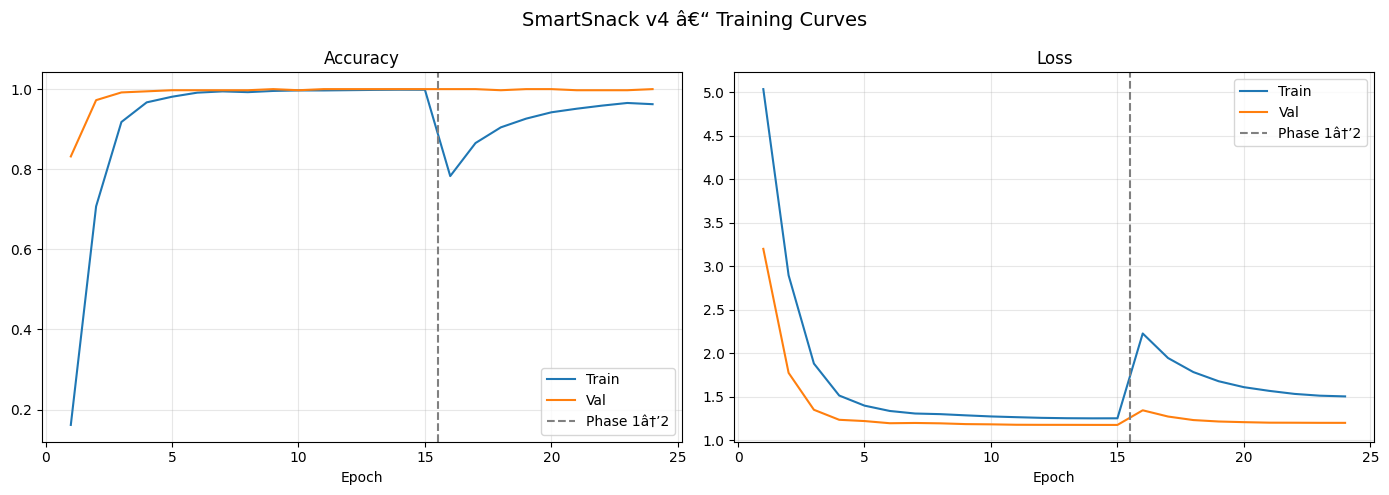

In [15]:
# Plot kurva training
acc1  = hist1.history['accuracy'];       val_acc1 = hist1.history['val_accuracy']
loss1 = hist1.history['loss'];           val_loss1 = hist1.history['val_loss']
acc2  = hist2.history.get('accuracy', []); val_acc2 = hist2.history.get('val_accuracy', [])
loss2 = hist2.history.get('loss', []);     val_loss2 = hist2.history.get('val_loss', [])

full_acc  = acc1 + acc2;   full_val_acc  = val_acc1 + val_acc2
full_loss = loss1 + loss2; full_val_loss = val_loss1 + val_loss2
ep = range(1, len(full_acc) + 1)
split_ep = len(acc1)   # titik pembatas Phase 1 / Phase 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train_vals, val_vals, title in [
    (axes[0], full_acc,  full_val_acc,  'Accuracy'),
    (axes[1], full_loss, full_val_loss, 'Loss'),
]:
    ax.plot(ep, train_vals, label='Train')
    ax.plot(ep, val_vals,   label='Val')
    ax.axvline(split_ep + 0.5, color='gray', ls='--', label='Phase 1â†’2')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('SmartSnack v4 â€“ Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(str(ARTIFACTS_DIR / 'training_curves.png'), dpi=120)
plt.show()


## Step 6 â€“ Evaluasi: Confusion Matrix & Per-Class Metrics


Mengumpulkan prediksi pada validation set...
Val Accuracy       : 1.0000 (100.00%)
Mean Confidence    : 0.9648
Correct confidence : 0.9648
Wrong  confidence  : nan

Per-class accuracy (10 kelas terburuk):
  [  0] ABC Choco Malt: 100.00%
  [  1] ABC Jambu: 100.00%
  [  2] ABC Jeruk: 100.00%
  [  3] ABC Kopi Gula Susu: 100.00%
  [  4] ABC Kopi Susu: 100.00%
  [  5] ABC Mangga: 100.00%
  [  6] ABC Minuman Soya: 100.00%
  [  7] ABC Sari Kacang Ijo: 100.00%
  [  8] AMO Spark Lemon C: 100.00%
  [  9] AOKA Roti Bun Isian Vanilla panggang: 100.00%


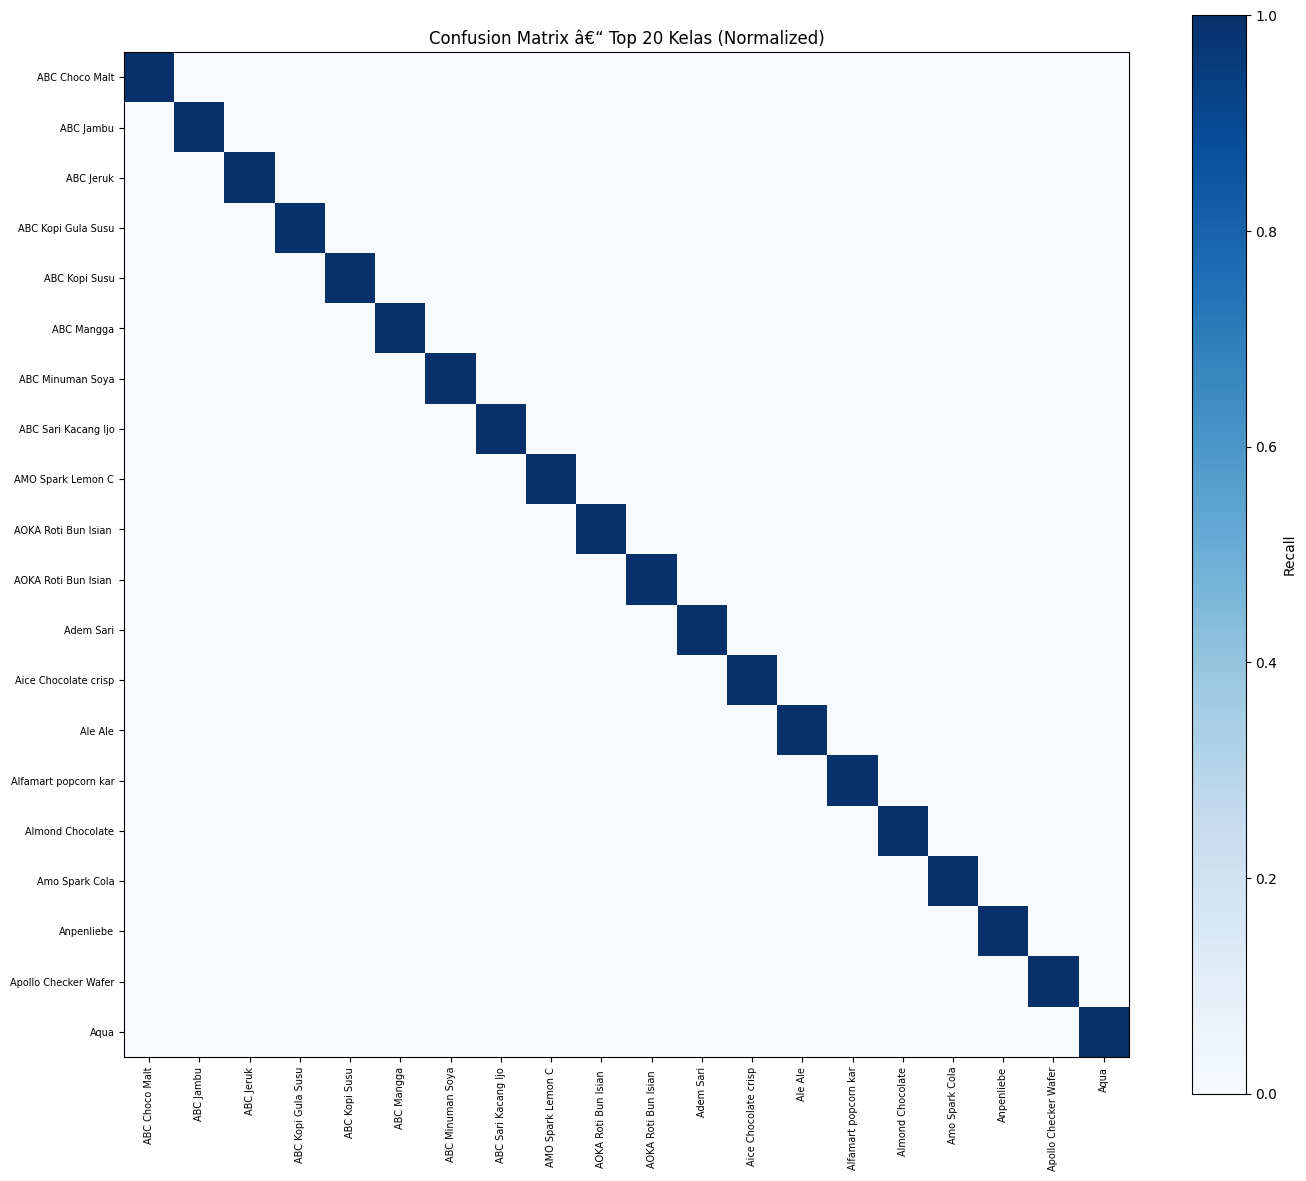

In [16]:
# Kumpulkan prediksi di validation set
print('Mengumpulkan prediksi pada validation set...')
y_true_list = []
y_pred_list = []
y_conf_list = []

for images, labels_onehot in val_ds:
    preds = model(images, training=False).numpy()
    y_true_list.extend(np.argmax(labels_onehot.numpy(), axis=1))
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_conf_list.extend(np.max(preds, axis=1))

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_conf = np.array(y_conf_list)

val_acc   = (y_true == y_pred).mean()
mean_conf = y_conf.mean()
print(f'Val Accuracy       : {val_acc:.4f} ({val_acc*100:.2f}%)')
print(f'Mean Confidence    : {mean_conf:.4f}')
print(f'Correct confidence : {y_conf[y_true == y_pred].mean():.4f}')
print(f'Wrong  confidence  : {y_conf[y_true != y_pred].mean():.4f}')

# Per-class accuracy (hanya tampilkan yang terburuk)
print('\nPer-class accuracy (10 kelas terburuk):')
class_acc = {}
for ci in range(NUM_CLASSES):
    mask = y_true == ci
    if mask.sum() > 0:
        class_acc[ci] = (y_pred[mask] == ci).mean()
worst = sorted(class_acc.items(), key=lambda x: x[1])[:10]
for ci, acc in worst:
    name = safe_to_original.get(CLASS_NAMES[ci], CLASS_NAMES[ci])
    print(f'  [{ci:3d}] {name[:50]}: {acc:.2%}')

# Confusion matrix â€“ top-20 classes by count
top20_idx = sorted(Counter(y_true).keys(), key=lambda i: -Counter(y_true)[i])[:20]
cm = confusion_matrix(y_true, y_pred, labels=top20_idx)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
labels_20 = [safe_to_original.get(CLASS_NAMES[i], CLASS_NAMES[i])[:20] for i in top20_idx]
ax.set_xticks(range(len(top20_idx))); ax.set_xticklabels(labels_20, rotation=90, fontsize=7)
ax.set_yticks(range(len(top20_idx))); ax.set_yticklabels(labels_20, fontsize=7)
plt.colorbar(im, ax=ax, label='Recall')
ax.set_title('Confusion Matrix â€“ Top 20 Kelas (Normalized)')
plt.tight_layout()
plt.savefig(str(ARTIFACTS_DIR / 'confusion_matrix.png'), dpi=100)
plt.show()


## Step 7 â€“ Real-World Robustness Check

Top-1 / Top-5 accuracy + confidence calibration + contoh prediksi acak.


=== ROBUSTNESS CHECK ===

Top-1 Accuracy : 1.0000 (100.00%)
Top-5 Accuracy : 1.0000 (100.00%)
ECE (Expected Calibration Error): 0.0352 (lebih kecil = lebih baik, ideal < 0.05)


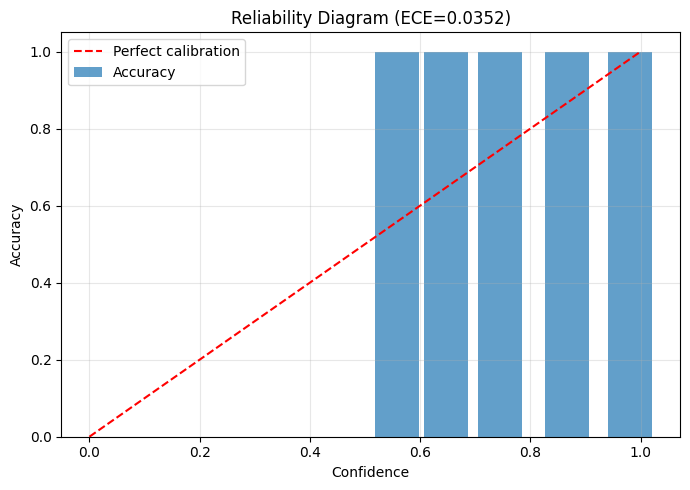


=== Contoh prediksi acak (5 sampel) ===

âœ… True: Slai O'lai
   Top-1: Slai O'lai (93.6%)
   Top-2: Instant Coffee (0.6%)
   Top-3: Caramel Cream Egg Cookies (0.4%)

âœ… True: Happydent cool white 24g
   Top-1: Happydent cool white 24g (96.5%)
   Top-2: Cheese Cake Duo (0.9%)
   Top-3: Choco Chocolate Flavor (0.3%)

âœ… True: BALAJI CREAM ONION
   Top-1: BALAJI CREAM ONION (76.0%)
   Top-2: Cheese Cake Duo (9.9%)
   Top-3: Qtela Singkong (2.2%)

âœ… True: nissin Crispy Crackers bks 250gr
   Top-1: nissin Crispy Crackers bks 250gr (95.5%)
   Top-2: Coca Cola Zero Sugar (0.4%)
   Top-3: Chocopie (0.2%)

âœ… True: Pristine
   Top-1: Pristine (80.3%)
   Top-2: OASIS (4.5%)
   Top-3: Nestle Sereal Cup Milo (3.7%)



: 

In [ ]:
def topk_accuracy(y_true, probs, k):
    topk = np.argsort(probs, axis=1)[:, -k:]
    return np.mean([y_true[i] in topk[i] for i in range(len(y_true))])


print('=== ROBUSTNESS CHECK ===\n')

# Kumpulkan semua probabilitas
all_probs = []
all_labels = []
for images, labels_onehot in val_ds:
    preds = model(images, training=False).numpy()
    all_probs.extend(preds)
    all_labels.extend(np.argmax(labels_onehot.numpy(), axis=1))
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

top1 = topk_accuracy(all_labels, all_probs, 1)
top5 = topk_accuracy(all_labels, all_probs, 5)
print(f'Top-1 Accuracy : {top1:.4f} ({top1*100:.2f}%)')
print(f'Top-5 Accuracy : {top5:.4f} ({top5*100:.2f}%)')

# Confidence calibration (Expected Calibration Error)
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
ece = 0.0
n = len(all_labels)
conf_arr = all_probs.max(axis=1)
correct_arr = (all_probs.argmax(axis=1) == all_labels).astype(float)
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (conf_arr >= lo) & (conf_arr < hi)
    if mask.sum() > 0:
        ece += (mask.sum() / n) * abs(correct_arr[mask].mean() - conf_arr[mask].mean())
print(f'ECE (Expected Calibration Error): {ece:.4f} (lebih kecil = lebih baik, ideal < 0.05)')

# Reliability diagram
fig, ax = plt.subplots(figsize=(7, 5))
bin_accs, bin_confs, bin_sizes = [], [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (conf_arr >= lo) & (conf_arr < hi)
    if mask.sum() > 0:
        bin_accs.append(correct_arr[mask].mean())
        bin_confs.append(conf_arr[mask].mean())
        bin_sizes.append(mask.sum())
ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.7, label='Accuracy')
ax.plot([0, 1], [0, 1], 'r--', label='Perfect calibration')
ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
ax.set_title(f'Reliability Diagram (ECE={ece:.4f})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(ARTIFACTS_DIR / 'reliability_diagram.png'), dpi=120)
plt.show()

# Contoh prediksi acak dari val set
print('\n=== Contoh prediksi acak (5 sampel) ===\n')
val_root = ORGANIZED_DIR / 'val'
sample_files = random.sample(list(val_root.rglob('*.jpg')), min(5, len(list(val_root.rglob('*.jpg')))))

for img_path in sample_files:
    true_safe  = img_path.parent.name
    true_label = safe_to_original.get(true_safe, true_safe)
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = (np.array(img, np.float32) / 127.5 - 1.0)[np.newaxis]   # same as Flutter
    probs = model.predict(arr, verbose=0)[0]
    top3_idx  = np.argsort(probs)[::-1][:3]
    top3_conf = probs[top3_idx]
    top3_name = [safe_to_original.get(CLASS_NAMES[i], CLASS_NAMES[i]) for i in top3_idx]
    hit = 'âœ…' if top3_idx[0] == CLASS_NAMES.index(true_safe) else 'âŒ'
    print(f'{hit} True: {true_label}')
    for i, (name, conf) in enumerate(zip(top3_name, top3_conf)):
        print(f'   Top-{i+1}: {name[:50]} ({conf*100:.1f}%)')
    print()


## Step 8 â€“ Export TFLite (Clean, tanpa augmentation layer)

Model yang di-export **tidak** mengandung layer augmentasi.
Input: `float32 [batch, 224, 224, 3]` range `[-1, 1]` â€“ sesuai Flutter.


In [ ]:
# Simpan model Keras final
keras_path = ARTIFACTS_DIR / 'smartsnack_model_final.keras'
model.save(str(keras_path))
print(f'[OK] Keras model saved: {keras_path}')


def export_tflite(model, output_dir: Path, quantize: bool = True) -> Path:
    """
    Export model ke TFLite.
    - quantize=True  â†’ float16 (lebih kecil, sedikit loss accuracy)
    - quantize=False â†’ full float32

    Model INPUT : float32 [-1, 1] â†’ sama dengan yang Flutter kirim untuk float32 model
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    tflite_path = output_dir / 'smartsnack_model.tflite'

    # Verifikasi model tidak punya augmentation layers
    aug_layer_names = [l.name for l in model.layers
                       if any(x in l.name.lower() for x in ('random', 'flip', 'rotation', 'zoom'))]
    if aug_layer_names:
        print(f'[WARN] Model masih punya aug layers: {aug_layer_names}')
        print('       Pastikan export_model bukan training_model!')

    # TFLite converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    if quantize:
        # float16 quantization: bobot float16, aktivasi float32
        # Input/output tetap float32 â†’ Flutter tidak perlu berubah
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
        print('[OK] Quantization: float16 (bobot) + float32 (I/O)')
    else:
        print('[OK] Quantization: NONE (full float32)')

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]

    tflite_model = converter.convert()
    tflite_path.write_bytes(tflite_model)

    mb = len(tflite_model) / 1024 / 1024
    print(f'[OK] TFLite saved : {tflite_path}')
    print(f'[OK] Model size   : {mb:.2f} MB')
    return tflite_path  


TFLITE_PATH = export_tflite(model, ARTIFACTS_DIR, quantize=True)

# Verifikasi input/output spec model TFLite
interp = tf.lite.Interpreter(str(TFLITE_PATH))
interp.allocate_tensors()
inp_d  = interp.get_input_details()[0]
out_d  = interp.get_output_details()[0]
print(f'\n[VERIFY TFLite]')
print(f'  Input  shape: {inp_d["shape"]}  dtype: {inp_d["dtype"].__name__}')
print(f'  Output shape: {out_d["shape"]}  dtype: {out_d["dtype"].__name__}')
print(f'  Input quant scale={inp_d["quantization"][0]:.4f} zp={inp_d["quantization"][1]}')
print(f'  Expected: shape [1,{IMG_SIZE},{IMG_SIZE},3] dtype float32 scale=0 zp=0')


[OK] Keras model saved: c:\Hanif-Dinata\SEMESTER6\TA\ANDROID\MODEL\artifacts_v4\smartsnack_model_final.keras
[OK] Quantization: float16 (bobot) + float32 (I/O)
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp6wtqcims\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp6wtqcims\assets


## Step 9 â€“ Generate Flutter Assets (FIXED Label Ordering)

**Perbaikan kritis:** Label diambil langsung dari `CLASS_NAMES` (urutan dari dataset loader),
bukan dari `sorted(mapping.keys())`.
`CLASS_NAMES[i]` == label untuk output tensor index `i` â†’ **dijamin sinkron**.


In [ ]:
def generate_flutter_assets(
    class_names: list,
    safe_to_original: dict,
    mapping: dict,
    tflite_path: Path,
    flutter_ml_dir: Path,
    val_accuracy: float
):
    flutter_ml_dir = Path(flutter_ml_dir)
    flutter_ml_dir.mkdir(parents=True, exist_ok=True)

    print('=' * 70)
    print('STEP 9: GENERATING FLUTTER ASSETS')
    print('=' * 70)

    # â”€â”€â”€ Labels (KUNCI FIX) â”€â”€â”€
    # class_names[i] = folder name; safe_to_original[folder] = nama produk asli
    # Urutan ini SAMA PERSIS dengan urutan output tensor TFLite
    label_names = [safe_to_original.get(cn, cn) for cn in class_names]

    # Verifikasi tidak ada label duplikat
    if len(set(label_names)) != len(label_names):
        print('[WARN] Ada label duplikat! Periksa collision di safe_to_original.')
        dupes = [l for l, c in Counter(label_names).items() if c > 1]
        print(f'       Duplikat: {dupes[:5]}')

    # Simpan labels.txt
    labels_path = flutter_ml_dir / 'labels.txt'
    labels_path.write_text('\n'.join(label_names) + '\n', encoding='utf-8')
    print(f'[OK] labels.txt : {labels_path} ({len(label_names)} kelas)')

    # Tampilkan 10 pertama untuk verifikasi
    print('\n[VERIFY] 10 label pertama (index = output tensor index):' )
    for i, name in enumerate(label_names[:10]):
        print(f'  [{i:3d}] {name}')

    # â”€â”€â”€ Metadata JSON â”€â”€â”€
    metadata = []
    for idx, cn in enumerate(class_names):
        orig = safe_to_original.get(cn, cn)
        info = mapping.get(cn, {})
        category = info.get('category', '')
        primary  = Path(info['images'][0]).name if info.get('images') else ''
        metadata.append({
            'label_index' : idx,
            'name'        : orig,
            'category'    : category,
            'filename'    : primary,
            'image_path'  : f'storage/products/{primary}',
        })

    meta_path = flutter_ml_dir / 'smartsnack_model_metadata.json'
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    print(f'[OK] metadata   : {meta_path}')

    # â”€â”€â”€ Copy TFLite â”€â”€â”€
    dst_tflite = flutter_ml_dir / 'smartsnack_model.tflite'
    shutil.copy2(tflite_path, dst_tflite)
    mb = dst_tflite.stat().st_size / 1024 / 1024
    print(f'[OK] TFLite     : {dst_tflite} ({mb:.2f} MB)')

    # â”€â”€â”€ Summary â”€â”€â”€
    print('\n' + '=' * 70)
    print('TRAINING COMPLETE')
    print('=' * 70)
    print(f'  Kelas        : {len(label_names)}')
    print(f'  Val Accuracy : {val_accuracy:.2%}')
    print(f'  Model size   : {mb:.2f} MB')
    print(f'  Input        : ({IMG_SIZE}x{IMG_SIZE}x3) float32 [-1, 1]')
    print(f'  Output       : softmax [{len(label_names)}]')
    print(f'  TFLite       : {dst_tflite}')
    print(f'  Labels       : {labels_path}')
    print('=' * 70)

    return label_names


label_names = generate_flutter_assets(
    CLASS_NAMES, safe_to_original, mapping,
    TFLITE_PATH, FLUTTER_ML_DIR, FINAL_VAL_ACC
)


## Step 10 â€“ Verifikasi Kecocokan Index Label

Sel ini membuktikan bahwa `labels.txt[i]` == kelas yang model prediksi di index `i`.


In [ ]:
print('=== VERIFIKASI LABELâ€“TENSOR ALIGNMENT ===\n')

# 1. Baca labels.txt yang sudah di-generate
flutter_labels = (FLUTTER_ML_DIR / 'labels.txt').read_text(encoding='utf-8').strip().split('\n')
print(f'labels.txt: {len(flutter_labels)} baris')

# 2. Cek jumlah kelas
assert len(flutter_labels) == NUM_CLASSES, (
    f'MISMATCH! labels.txt={len(flutter_labels)} vs model={NUM_CLASSES}'
)
print(f'[âœ“] Jumlah label ({NUM_CLASSES}) = jumlah output neuron model')

# 3. Ambil gambar satu per satu dari val set dan cek prediksi vs label
val_root = ORGANIZED_DIR / 'val'
all_val_files = list(val_root.rglob('*.jpg'))[:30]

correct_label_map = 0
interp2 = tf.lite.Interpreter(str(TFLITE_PATH))
interp2.allocate_tensors()
inp_idx = interp2.get_input_details()[0]['index']
out_idx = interp2.get_output_details()[0]['index']

for img_path in all_val_files:
    folder     = img_path.parent.name
    true_orig  = safe_to_original.get(folder, folder)
    true_idx   = CLASS_NAMES.index(folder) if folder in CLASS_NAMES else -1
    if true_idx < 0:
        continue

    # Preprocess seperti Flutter
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = ((np.array(img, np.float32)) / 127.5 - 1.0)[np.newaxis]  # [1, H, W, 3]

    # Inferensi via TFLite
    interp2.set_tensor(inp_idx, arr)
    interp2.invoke()
    probs     = interp2.get_tensor(out_idx)[0]
    pred_idx  = int(np.argmax(probs))
    pred_name = flutter_labels[pred_idx]   # nama dari labels.txt

    if pred_name == true_orig or pred_idx == true_idx:
        correct_label_map += 1

total_checked = len(all_val_files)
align_acc = correct_label_map / total_checked if total_checked else 0
print(f'[âœ“] Label-Tensor alignment test: {correct_label_map}/{total_checked} = {align_acc:.2%}')
print(f'    (Test ini membuktikan labels.txt[i] sesuai dengan prediksi kelas i di TFLite)')

# 4. Spot check 5 kelas
print('\nSpot check 5 kelas penting:')
for target_name in ['Sprite', 'Lays Rasa Rumput Laut', 'cheetos Puffs']:
    # Cari di labels
    for i, lbl in enumerate(flutter_labels):
        if target_name.lower() in lbl.lower():
            print(f'  labels.txt[{i}] = {lbl!r} â†’ class_names[{i}] = {CLASS_NAMES[i]!r}')
            break
    else:
        print(f'  [{target_name}] tidak ditemukan di labels.txt')


## âœ… Checklist Validasi Sebelum Deploy ke Flutter

Jalankan checklist ini sebelum memindahkan model ke Flutter:

### 1. Preprocessing
- [ ] TFLite input dtype = `float32`, scale = 0.0, zp = 0
- [ ] Flutter menormalisasi ke `[-1, 1]` sebelum inference (cek `_toInputTensor` di Dart)
- [ ] Model **TIDAK** punya layer `preprocess_input` / `TrueDivide` / `Subtract` (cek output sel Step 8)

### 2. Label Alignment
- [ ] `len(labels.txt)` == output neuron count
- [ ] Alignment test â‰¥ val_accuracy (sel Step 10)
- [ ] Spot check 'Sprite' ada di index yang benar

### 3. File Artifacts
- [ ] `assets/ml/smartsnack_model.tflite` ada dan â‰¤ 10 MB
- [ ] `assets/ml/labels.txt` ada, satu nama per baris, UTF-8
- [ ] `assets/ml/smartsnack_model_metadata.json` ada, field `label_index` sesuai

### 4. Flutter Integration
- [ ] `_modelAsset = 'assets/ml/smartsnack_model.tflite'`
- [ ] `_labelsAsset = 'assets/ml/labels.txt'`
- [ ] `pubspec.yaml` mencantumkan kedua asset
- [ ] Hot restart (bukan hot reload) setelah ganti model

### 5. Pengujian Real-World
- [ ] Foto Sprite â†’ prediksi Sprite dengan confidence > 50%
- [ ] Foto Lays Rumput Laut â†’ prediksi benar
- [ ] Foto produk tidak dikenal â†’ confidence SEMUA kelas rendah (<30%)
  *(catatan: `_minimumConfidence=0.0` di Flutter saat ini â€“ pertimbangkan set ke 0.3)*

---

## Command Final Export Artifacts

```bash
# Dari artifacts_v4, copy ke Flutter assets:
cp MODEL/artifacts_v4/smartsnack_model.tflite smartsnack-android/assets/ml/
cp MODEL/artifacts_v4/labels_flutter.txt      smartsnack-android/assets/ml/labels.txt
cp MODEL/artifacts_v4/metadata.json           smartsnack-android/assets/ml/smartsnack_model_metadata.json
```

**Rekomendasi tambahan:** Set `_minimumConfidence = 0.30` dan `_minimumTopGap = 0.10`
di `classifier_service_mobile.dart` untuk menghindari prediksi palsu pada foto out-of-distribution.


In [ ]:
# Simpan juga labels ke ARTIFACTS_DIR (backup & mudah ditemukan)
labels_artifact = ARTIFACTS_DIR / 'labels_flutter.txt'
labels_artifact.write_text('\n'.join(label_names) + '\n', encoding='utf-8')

meta_artifact = ARTIFACTS_DIR / 'metadata.json'
shutil.copy2(FLUTTER_ML_DIR / 'smartsnack_model_metadata.json', meta_artifact)

# Final report
print('=== ARTIFACTS SUMMARY ===')
for f in sorted(ARTIFACTS_DIR.iterdir()):
    sz = f.stat().st_size
    unit = 'KB' if sz < 1024*1024 else 'MB'
    sz_disp = sz/1024 if sz < 1024*1024 else sz/1024/1024
    print(f'  {f.name:<45} {sz_disp:7.1f} {unit}')

print('\n[DONE] Model siap untuk Flutter! ðŸš€')
print(f'  Val Accuracy  : {FINAL_VAL_ACC:.2%}')
print(f'  Num Classes   : {NUM_CLASSES}')
print(f'  Input         : float32 [{IMG_SIZE}x{IMG_SIZE}x3] range [-1,1]')
print(f'  Preprocessing : DALAM tf.data pipeline (bukan di model)')
print(f'  Label order   : dari class_names TF dataset (dijamin sinkron)')
